In [8]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#froms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import silhouette_score

In [10]:
# globales
df = pd.read_csv("../../data/dataset_processed.csv", encoding="ISO-8859-1", low_memory=False)
print(f'\n DF limpio:')
print(df.info())


 DF limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376579 entries, 0 to 376578
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   376579 non-null  int64  
 1   InvoiceNo    376579 non-null  object 
 2   StockCode    376579 non-null  object 
 3   Description  376579 non-null  object 
 4   Quantity     376579 non-null  int64  
 5   InvoiceDate  376579 non-null  object 
 6   UnitPrice    376579 non-null  float64
 7   CustomerID   376579 non-null  float64
 8   Country      376579 non-null  object 
 9   TotalSales   376579 non-null  float64
 10  Year         376579 non-null  int64  
 11  Month        376579 non-null  int64  
 12  Day          376579 non-null  int64  
 13  DayOfWeek    376579 non-null  int64  
 14  Quarter      376579 non-null  int64  
 15  Season       376579 non-null  object 
dtypes: float64(3), int64(7), object(6)
memory usage: 46.0+ MB
None


In [12]:
mask = df['Country'] == "United Kingdom"
df = df[mask]
df = df.set_index("Unnamed: 0")

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,Day,DayOfWeek,Quarter,Season
Unnamed: 0,,,,,,,,,,,,,,,
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2,4,Winter
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2,4,Winter
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter


In [14]:
#config
df_grouped = df.groupby(['InvoiceNo', 'CustomerID'])['TotalSales'].sum().reset_index()
df_grouped

df_to_use = df_grouped.groupby(['CustomerID']).agg({
  "TotalSales": "sum",
  "InvoiceNo": "count"
}).reset_index()

df_to_use

,CustomerID,TotalSales,InvoiceNo
0,12747.0,1959.01,11
1,12748.0,24712.23,214
2,12749.0,3615.00,8
3,12820.0,942.34,4
4,12821.0,92.72,1
...,...,...,...
3834,18280.0,180.60,1
3835,18281.0,80.82,1
3836,18282.0,176.60,3
3837,18283.0,2045.53,16


In [16]:
df_to_use['mediaTicket'] = df_to_use['TotalSales']/df_to_use['InvoiceNo']

In [18]:
df_to_use = df_to_use.sort_values('InvoiceNo')
df_to_use

,CustomerID,TotalSales,InvoiceNo,mediaTicket
1545,15052.0,127.83,1,127.830000
2264,16054.0,783.90,1,783.900000
831,14027.0,104.82,1,104.820000
2265,16055.0,134.80,1,134.800000
2266,16056.0,650.75,1,650.750000
...,...,...,...,...
184,13089.0,33447.93,101,331.167624
1736,15311.0,13809.91,113,122.211593
1242,14606.0,10969.59,127,86.374724
3525,17841.0,35847.31,169,212.114260


In [20]:
camposUsar = df_to_use[['TotalSales', 'InvoiceNo', 'mediaTicket']]

# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_to_use["Cluster"] = kmeans.fit_predict(camposUsar)

# Agregar las etiquetas al dataframe
df_to_use["Cluster"] = kmeans.labels_

# Evaluar la inercia del modelo
kmeans.inertia_

1843027075.345057

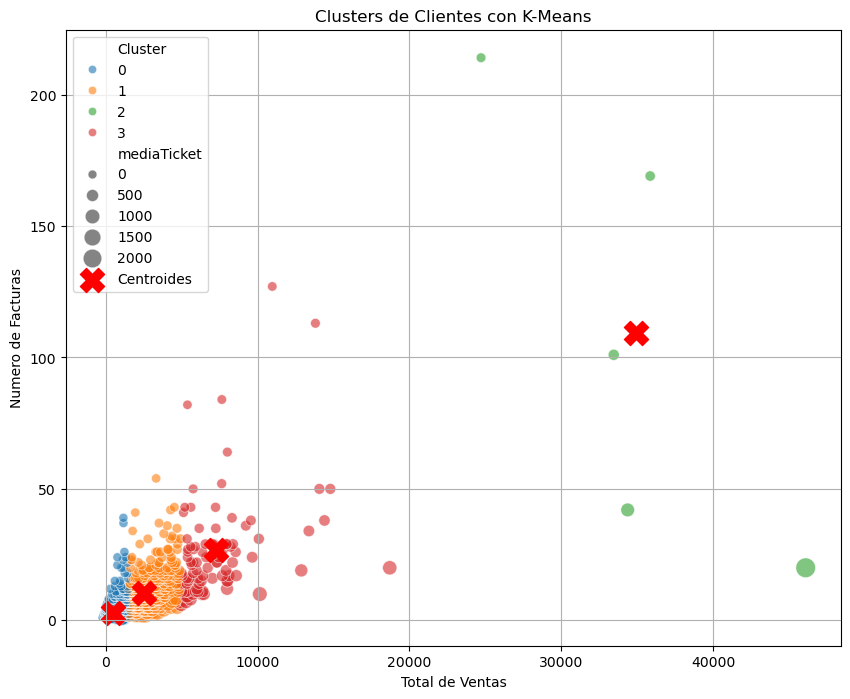

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TotalSales', 
    y='InvoiceNo', 
    hue='Cluster',
    size='mediaTicket',
    sizes=(20, 200),
    alpha=0.6,
    palette='tab10',
    data=df_to_use
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroides')

plt.xlabel("Total de Ventas")
plt.ylabel("Numero de Facturas")
plt.title("Clusters de Clientes con K-Means")
plt.legend(loc='upper left')
plt.grid()
plt.show()

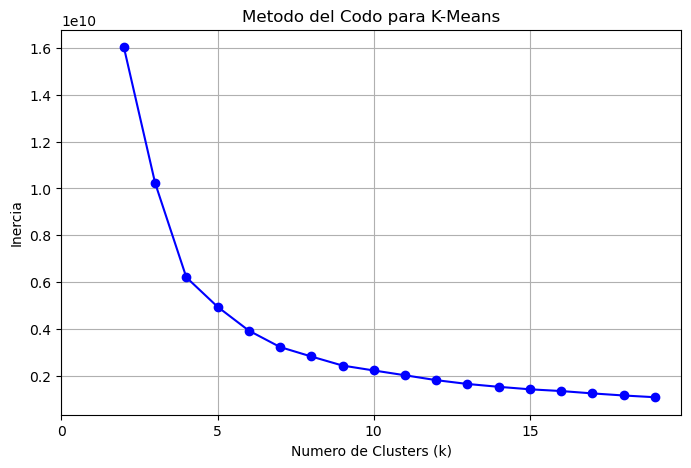

In [24]:
# Rango de valores de k que quieres probar
k_values = range(2, 20)  # Puedes ajustarlo segun lo necesites
inertia_values = []

# Calcular inercia para cada valor de k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # definicion del modelo
    kmeans.fit(df_to_use) # entrenamiento
    inertia_values.append(kmeans.inertia_) # guardamos la inercia

# Grafica
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del Codo para K-Means')
plt.xticks(np.arange(0, 20, step=5))  # Ajusta los ticks para mejor visualización
plt.grid()
plt.show()

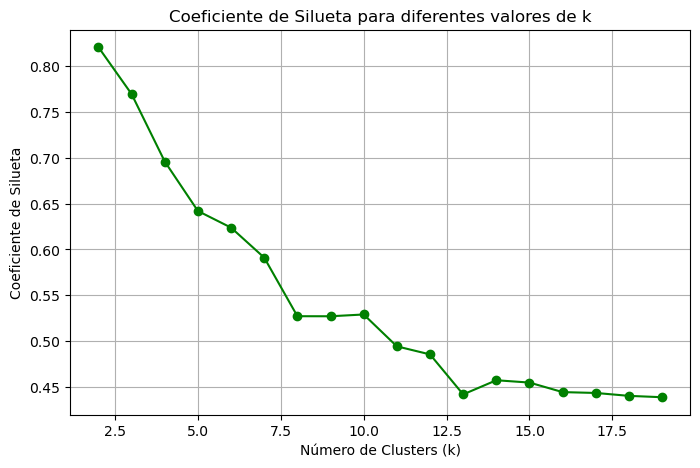

Best k=2, silhouette value= 0.8208


In [30]:

best_k = None
best_silhouette = -1
silhouette_scores = []

for k in range(2, 20):  # Evaluamos entre 2 y 20 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(camposUsar) # Entrenamos cada modelo
    silhouette = silhouette_score(camposUsar, labels) # calcula el indice de silueta
    silhouette_scores.append(silhouette)
    
    if silhouette > best_silhouette: # Cuanto mayor indice de silueta mejor
        best_silhouette = silhouette
        best_k = k

# Grafica
plt.figure(figsize=(8, 5))
plt.plot(range(2, 20), silhouette_scores, marker='o', linestyle='-', color='g')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Coeficiente de Silueta para diferentes valores de k')
plt.grid()
plt.show()

print(f"Best k={best_k}, silhouette value= {best_silhouette:.4f}")